In [26]:
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dowhy import CausalModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor


# Reproducibility and runtime control
RANDOM_STATE = 1
SAMPLE_SIZE = 20000

# Variables used as common causes / effect modifiers
# NOTE: city_id is a categorical identifier. Its numeric mean is not directly interpretable.
COMMON_CAUSES = [
    "distance_to_center",
    "avg_rating",
    "stars",
    "n_reviews",
    "avg_price",
    "city_id",
]


## Causal Inference Notebook Guide
- Goal: estimate the causal effect of `content_score` on `n_clicks`.
- ATE: overall average treatment effect.
- CATE: heterogeneous effect by hotel/context features.
- Important caveat: `city_id` is categorical, so interpret it via distribution, not numeric mean.


In [27]:
# 1) Load and prepare data
start_time = datetime.now()

# Keep only complete rows for a clean baseline run.
# If missingness itself is informative, use imputation + missing indicators instead.
df = pd.read_csv("./data/train_set.csv").dropna().reset_index(drop=True)

# Sample down for faster iteration while preserving reproducibility.
df_ci = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)

print(df_ci.shape)
print(df_ci[COMMON_CAUSES + ["content_score", "n_clicks"]].head())


(20000, 12)
   distance_to_center  avg_rating  stars  n_reviews  avg_price   city_id  \
0              2037.0        83.0    0.0     1773.0      75.44   29774.0   
1              1135.0        81.0    0.0       87.0      27.20  122984.0   
2              1618.0        85.0    0.0       93.0      62.88   52872.0   
3             85562.0        85.0    0.0      108.0      46.77  843148.0   
4              1736.0        80.0    0.0     1509.0     100.26   63288.0   

   content_score  n_clicks  
0           58.0         2  
1           49.0         0  
2           61.0         0  
3           24.0         0  
4           59.0         2  


In [28]:
# 2) Build causal graph and identify estimand
model = CausalModel(
    data=df_ci,
    treatment="content_score",
    outcome="n_clicks",
    common_causes=COMMON_CAUSES,
)

identified = model.identify_effect()
print(identified)



Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                                   
────────────────(E[n_clicks|distance_to_⟨center,stars,⟩_rating,n_reviews,city_⟨id,⟩_price])
d[content_score]                                                                           
Estimand assumption 1, Unconfoundedness: If U→{content_score} and U→n_clicks then P(n_clicks|content_score,distance_to_center,stars,avg_rating,n_reviews,city_id,avg_price,U) = P(n_clicks|content_score,distance_to_center,stars,avg_rating,n_reviews,city_id,avg_price)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                                                                                   
────────────────(E[n_clicks|distance_to_⟨center,sta

In [29]:
# 3) Estimate ATE with DML + linear final model
estimate_ate = model.estimate_effect(
    identified,
    method_name="backdoor.econml.dml.DML",
    method_params={
        "init_params": {
            "model_y": RandomForestRegressor(
                n_estimators=20, random_state=RANDOM_STATE, min_samples_leaf=20
            ),
            "model_t": RandomForestRegressor(
                n_estimators=20, random_state=RANDOM_STATE, min_samples_leaf=20
            ),
            "model_final": LinearRegression(fit_intercept=False),
            "discrete_treatment": False,
            "cv": 3,
            "random_state": RANDOM_STATE,
        },
        "fit_params": {"inference": "bootstrap"},
    },
)

print("ATE:", estimate_ate.value)
print("Time taken:", datetime.now() - start_time)
print(estimate_ate.estimator.estimator.summary())



c:\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(esti

ATE: 0.4993189186292097
Time taken: 0:01:37.221732
                                           Coefficient Results                                           
point_estimate stderr zstat pvalue ci_lower ci_upper
----------------------------------------------------
                       CATE Intercept Results                      
               point_estimate stderr zstat pvalue ci_lower ci_upper
-------------------------------------------------------------------
cate_intercept          0.499  0.201 2.481   0.01    0.173    0.901
-------------------------------------------------------------------

<sub>A linear parametric conditional average treatment effect (CATE) model was fitted:
$Y = \Theta(X)\cdot T + g(X, W) + \epsilon$
where for every outcome $i$ and treatment $j$ the CATE $\Theta_{ij}(X)$ has the form:
$\Theta_{ij}(X) = X' coef_{ij} + cate\_intercept_{ij}$
Coefficient Results table portrays the $coef_{ij}$ parameter vector for each outcome $i$ and treatment $j$. Intercept Result

In [30]:
# 4) Refutation checks
# Refuters can be slow; run one-by-one when iterating.
# Recommended order: placebo_treatment_refuter -> random_common_cause

# refute_placebo = model.refute_estimate(
#     identified,
#     estimate_ate,
#     method_name="placebo_treatment_refuter",
#     show_progress_bar=True,
#     placebo_type="permute",
# )
# print(refute_placebo)

# refute_random_common_cause = model.refute_estimate(
#     identified,
#     estimate_ate,
#     method_name="random_common_cause",
#     show_progress_bar=True,
# )
# print(refute_random_common_cause)


In [ ]:
# 5) Estimate CATE with XGBoost as final model
estimate_xgb = model.estimate_effect(
    identified,
    method_name="backdoor.econml.dml.DML",
    method_params={
        "init_params": {
            "model_y": RandomForestRegressor(
                n_estimators=20, random_state=RANDOM_STATE, min_samples_leaf=20
            ),
            "model_t": RandomForestRegressor(
                n_estimators=20, random_state=RANDOM_STATE, min_samples_leaf=20
            ),
            "model_final": XGBRegressor(
                n_estimators=50,
                max_depth=2,
                min_child_weight=10,
                learning_rate=0.05,
                reg_lambda=10,
                random_state=RANDOM_STATE,
            ),
            "discrete_treatment": False,
            "cv": 3,
            "random_state": RANDOM_STATE,
        },
        "fit_params": {"inference": "bootstrap"},
    },
    effect_modifiers=COMMON_CAUSES,
)

print(estimate_xgb)
# refute_xgb = model.refute_estimate(identified, estimate_xgb, method_name="random_common_cause")
# print(refute_xgb)



c:\Python312\Lib\site-packages\econml\dml\dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
c:\Python312\Lib\site-packages\econml\dml\dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
c:\Python312\Lib\site-packages\econml\dml\dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
c:\Python312\Lib\site-packages\econml\dml\dml.py:192: UserWarning: The final model has a nonzero intercept for at l

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                                   
────────────────(E[n_clicks|distance_to_⟨center,stars,⟩_rating,n_reviews,city_⟨id,⟩_price])
d[content_score]                                                                           
Estimand assumption 1, Unconfoundedness: If U→{content_score} and U→n_clicks then P(n_clicks|content_score,distance_to_center,stars,avg_rating,n_reviews,city_id,avg_price,U) = P(n_clicks|content_score,distance_to_center,stars,avg_rating,n_reviews,city_id,avg_price)

## Realized estimand
b: n_clicks~content_score+distance_to_center+stars+avg_rating+n_reviews+city_id+avg_price | distance_to_center,avg_rating,stars,n_reviews,avg_price,city_id
Target units: ate

## Estimate
Mean value: 1.4231345360517502
Effect estimates: [[0.       ]
 [0.       ]
 [0.       ]
 ...

c:\Python312\Lib\site-packages\econml\dml\dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
c:\Python312\Lib\site-packages\econml\dml\dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "


In [16]:
# 6) Analyze high-effect segment from XGB CATE
df_ci["cate_effect_xgb"] = estimate_xgb.estimator.effect(df_ci[COMMON_CAUSES])
print(df_ci["cate_effect_xgb"].describe())

high_effect_xgb = df_ci[(df_ci["cate_effect_xgb"] > 0.01) & (df_ci["cate_effect_xgb"] < 50.0)]

# city_id is categorical, so compare means only on continuous features.
analysis_cols = [c for c in COMMON_CAUSES if c != "city_id"]
comparison_xgb = pd.concat(
    [
        df_ci[analysis_cols].mean().rename("overall_mean"),
        high_effect_xgb[analysis_cols].mean().rename("high_effect_group_mean"),
    ],
    axis=1,
)
print("--- High-effect group vs overall mean (XGB CATE) ---")
print(comparison_xgb)
print(f"Selected hotels: {len(high_effect_xgb)}")

print("Top city_id share in high-effect group (for categorical diagnostics):")
print(high_effect_xgb["city_id"].value_counts(normalize=True).head(5))


count    5000.000000
mean        1.423135
std        17.213627
min        -0.840250
25%         0.000000
50%         0.000000
75%         0.000000
max       595.135376
Name: cate_effect_xgb, dtype: float64
--- High-effect group vs overall mean (XGB CATE) ---
                     overall_mean  high_effect_group_mean
distance_to_center   12837.425800            65874.852064
avg_rating              81.622800               81.322248
stars                    1.526600                1.600917
n_reviews             1234.983600             1731.928899
avg_price              102.345966              102.029553
city_id             145264.489200           129881.837156
Selected hotels: 872


In [31]:
# 7) Estimate CATE with linear final model
# Use no intercept in the final stage to avoid econml intercept warning.
estimate_linear = model.estimate_effect(
    identified_estimand=identified,
    method_name="backdoor.econml.dml.DML",
    target_units="ate",
    effect_modifiers=COMMON_CAUSES,
    method_params={
        "init_params": {
            "model_y": RandomForestRegressor(
                n_estimators=20, random_state=RANDOM_STATE, min_samples_leaf=20
            ),
            "model_t": RandomForestRegressor(
                n_estimators=20, random_state=RANDOM_STATE, min_samples_leaf=20
            ),
            "model_final": LinearRegression(fit_intercept=False),
            "fit_cate_intercept": False,
            "discrete_treatment": False,
            "cv": 3,
            "random_state": RANDOM_STATE,
        },
        "fit_params": {"inference": "auto"},
    },
)

print(estimate_linear.estimator.estimator.summary())


c:\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


       Coefficient Results       
                   point_estimate
---------------------------------
distance_to_center           -0.0
avg_rating                  0.023
stars                       0.115
n_reviews                     0.0
avg_price                   0.001
city_id                      -0.0
    CATE Intercept Results   
               point_estimate
-----------------------------
cate_intercept         -1.745
-----------------------------

<sub>A linear parametric conditional average treatment effect (CATE) model was fitted:
$Y = \Theta(X)\cdot T + g(X, W) + \epsilon$
where for every outcome $i$ and treatment $j$ the CATE $\Theta_{ij}(X)$ has the form:
$\Theta_{ij}(X) = X' coef_{ij} + cate\_intercept_{ij}$
Coefficient Results table portrays the $coef_{ij}$ parameter vector for each outcome $i$ and treatment $j$. Intercept Results table portrays the $cate\_intercept_{ij}$ parameter.</sub>


c:\Python312\Lib\site-packages\econml\dml\dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
c:\Python312\Lib\site-packages\econml\inference\_inference.py:401: UserWarning: Final model doesn't have a `coef_stderr_` and `intercept_stderr_` attributes, only point estimates will be available.
  warn("Final model doesn't have a `coef_stderr_` and `intercept_stderr_` attributes, "
c:\Python312\Lib\site-packages\econml\inference\_inference.py:447: UserWarning: Final model doesn't have a `coef_stderr_` and `intercept_stderr_` attributes, only point estimates will be available.
  warn("Final model doesn't have a `coef_stderr_` and `intercept_stderr_` attributes, "


## Interpretation Notes
- Refutation is required before claiming robust causal conclusions.
- Segment thresholds are set by quantile to avoid arbitrary cutoffs.
## Interpretation Notes
- Refutation is required before claiming robust causal conclusions.
- Segment thresholds are set by quantile to avoid arbitrary cutoffs.
- Visuals use `log(1+n_reviews)` and jitter for readability.


In [32]:
# 8) Analyze high-effect segment from linear CATE
df_ci["cate_effect_linear"] = estimate_linear.estimator.effect(df_ci[COMMON_CAUSES])
print(df_ci["cate_effect_linear"].describe())

# Robust thresholding: use top 20% within positive effects.
positive_effects = df_ci.loc[df_ci["cate_effect_linear"] > 0, "cate_effect_linear"]
effect_cutoff = positive_effects.quantile(0.8) if len(positive_effects) > 0 else np.inf
high_effect_linear = (
    df_ci[df_ci["cate_effect_linear"] >= effect_cutoff].copy()
    if np.isfinite(effect_cutoff)
    else df_ci.iloc[0:0].copy()
)

analysis_cols = [c for c in COMMON_CAUSES if c != "city_id"]
comparison_linear = pd.concat(
    [
        df_ci[analysis_cols].mean().rename("overall_mean"),
        high_effect_linear[analysis_cols].mean().rename("high_effect_group_mean"),
    ],
    axis=1,
)
print("--- High-effect group vs overall mean (Linear CATE) ---")
print(comparison_linear)
print(f"Selected hotels: {len(high_effect_linear)}")
print(f"Effect cutoff (top 20% of positive effects): {effect_cutoff:.4f}")

print("Top city_id share in high-effect group (for categorical diagnostics):")
print(high_effect_linear["city_id"].value_counts(normalize=True).head(5))

# For business interpretation, aggregate positive uplift only.
total_positive_lift = df_ci.loc[df_ci["cate_effect_linear"] > 0, "cate_effect_linear"].sum()
target_positive_lift = high_effect_linear["cate_effect_linear"].clip(lower=0).sum()
share_hotels = len(high_effect_linear) / len(df_ci) * 100 if len(df_ci) > 0 else 0
share_lift = target_positive_lift / total_positive_lift * 100 if total_positive_lift != 0 else 0
print(f"Total expected positive click lift (all hotels): {total_positive_lift:.0f}")
print(f"Total expected positive click lift (targeted group): {target_positive_lift:.0f}")
print(f"Top {share_hotels:.1f}% hotels explain {share_lift:.1f}% of positive estimated lift")


count    20000.000000
mean         0.663102
std          0.859322
min         -2.375089
25%          0.227297
50%          0.454593
75%          0.882640
max         18.628974
Name: cate_effect_linear, dtype: float64
--- High-effect group vs overall mean (Linear CATE) ---
                     overall_mean  high_effect_group_mean
distance_to_center   10126.662300             4308.615094
avg_rating              81.711900               82.583720
stars                    1.515350                2.630296
n_reviews             1258.355700             2348.654232
avg_price              101.297637              131.961584
city_id             142901.375600            75868.505013
Selected hotels: 9275
Total expected click lift (all hotels): 13262
Total expected click lift (targeted group): 11277
Top 46.4% hotels explain 85.0% of estimated lift


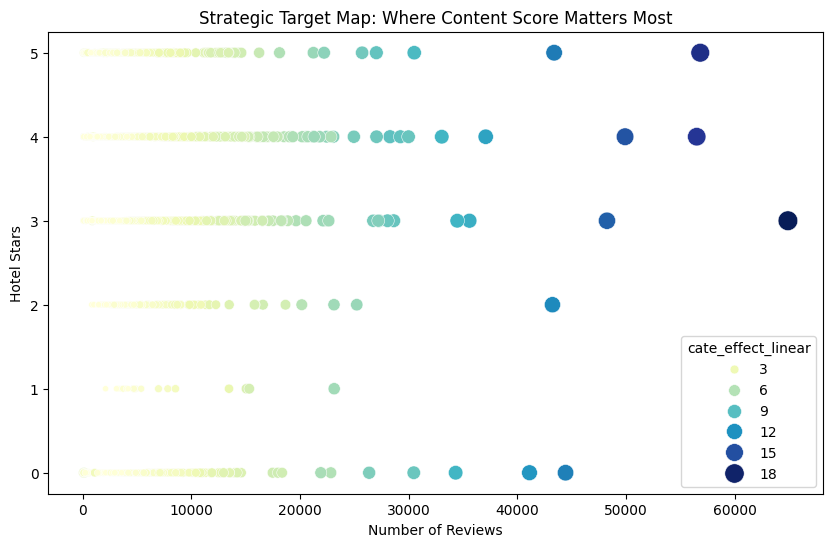

In [33]:
# 9) Visualize where the effect is concentrated
# Plot only the selected segment with log-scaled review counts for readability.
plot_df = high_effect_linear.copy()
plot_df["log_n_reviews"] = np.log1p(plot_df["n_reviews"])
rng = np.random.default_rng(RANDOM_STATE)
plot_df["stars_jitter"] = plot_df["stars"] + rng.uniform(-0.08, 0.08, size=len(plot_df))

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="log_n_reviews",
    y="stars_jitter",
    hue="cate_effect_linear",
    palette="YlGnBu",
    alpha=0.8,
)
plt.title("Strategic Target Map: Where Content Score Matters Most")
plt.xlabel("log(1 + Number of Reviews)")
plt.ylabel("Hotel Stars (jittered)")
plt.show()


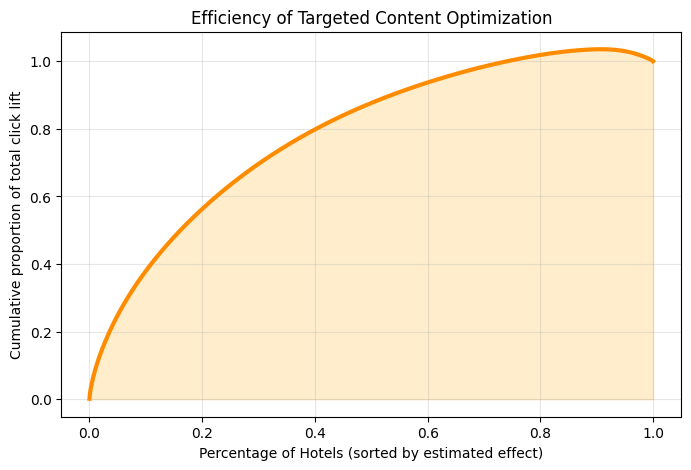

In [34]:
# 10) Cumulative impact curve
# Rank by estimated effect and check how quickly uplift accumulates.
df_sorted = df_ci.sort_values("cate_effect_linear", ascending=False).reset_index(drop=True)
total_effect = df_sorted["cate_effect_linear"].clip(lower=0).sum()

if total_effect != 0:
    df_sorted["cumulative_effect"] = df_sorted["cate_effect_linear"].clip(lower=0).cumsum() / total_effect
    df_sorted["percentile"] = (df_sorted.index + 1) / len(df_sorted)

    plt.figure(figsize=(8, 5))
    plt.plot(df_sorted["percentile"], df_sorted["cumulative_effect"], color="darkorange", lw=3)
    plt.fill_between(
        df_sorted["percentile"],
        df_sorted["cumulative_effect"],
        color="orange",
        alpha=0.2,
    )
    plt.title("Efficiency of Targeted Content Optimization")
    plt.xlabel("Percentage of Hotels (sorted by estimated effect)")
    plt.ylabel("Cumulative proportion of positive click lift")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Cumulative impact plot skipped because total positive effect is zero.")


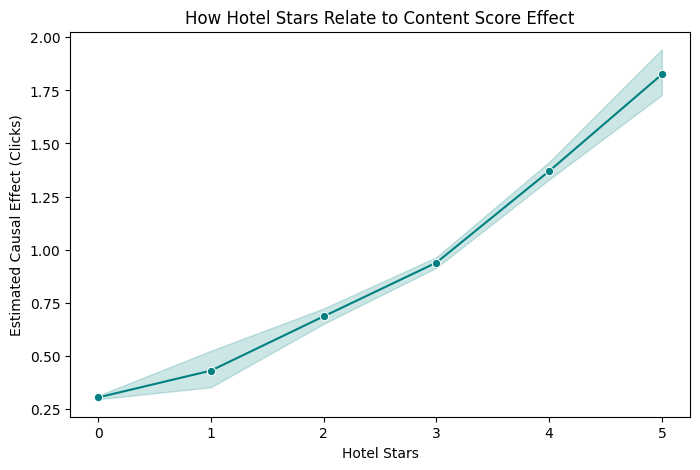

In [35]:
# 11) Effect trend by hotel stars
# stars can include 0 as unknown/missing-coded values; keep it visible for diagnostics.
trend = df_ci.groupby("stars", as_index=False)["cate_effect_linear"].mean()

plt.figure(figsize=(8, 5))
sns.lineplot(data=trend, x="stars", y="cate_effect_linear", marker="o", color="teal")
plt.title("How Hotel Stars Relate to Content Score Effect")
plt.ylabel("Mean Estimated Causal Effect (Clicks)")
plt.xlabel("Hotel Stars")
plt.show()
